### A Hebbian learning network with 1 layer

Part 1: Simulating the input data $\mathbf{x}$ and the target output $\mathbf{y}$

Part 2: Implementing Oja's Learning Rule

Part 3: Implementing Sanger's Rule

Part 4: Training the Network, and visualizing the Loss

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod
from hebbian.models import HebbianModel, OjaNetwork, SangerNetwork

### Model Structure

In [2]:
# HebbianModel

### Oja's multi-neuron model
$$
\mathbf{x \in \mathbb{R}^n}
$$

$$
\mathbf{y = Wx \in \mathbb{R}^m}
$$

$$
\mathbf{yx^\top \in \mathbb{R}^{m \times n}}
$$
$$
\mathbf{W \in \mathbb{R}^{m \times n}}
$$
$$
\mathbf{yy^\top = \mathbb{R}^{m \times m}}
$$

$$
\mathbf{\Delta W = \eta (yx^\top - y y^\top W)}
$$


In [3]:
# OjaNetwork

### Sanger's multi-neuron model

$$
\mathbf{yy^\top = \begin{bmatrix}
    y_1 y_1 & y_1 y_2 & \cdots & y_1 y_k \\
    y_2 y_1 & y_2 y_2 & \cdots & y_2 y_k \\
    \vdots & \vdots & \ddots & \vdots \\
    y_k y_1 & y_k y_2 & \cdots & y_k y_k
\end{bmatrix}}
$$

$$
\mathbf{B = \begin{bmatrix}
    y_1 y_1 & 0 & \cdots & 0 \\
    y_2 y_1 & y_2 y_2 & \cdots & 0 \\
    \vdots & \vdots & \ddots & \vdots \\
    y_k y_1 & y_k y_2 & \cdots & y_k y_k
\end{bmatrix}}
$$

$$
\mathbf{\Delta W = \eta (y x^\top - B W)}
$$



In [4]:
# SangerNetwork

### Training and testing: alignment to PCs

In [5]:
from hebbian.utils import pca_topk,  plot_samples_and_top2_pcs, plot_samples_and_top3_pcs_3d, generate_covariance_matrix, cosine_alignment, correlation_alignment, visualize_alignment

def training_testing(
    samples,
    models=None,                 # list/dict of model classes or instances
    output_size=None,
    alignment_method="weights",
    pc_method="ordered",
    show_num=None
):
    """
    Run training/testing over one or more models and visualize alignment per model.

    Parameters
    ----------
    samples : np.ndarray
        Data matrix of shape (n_samples, n_features).
    models : list | dict
        - If list: [ModelClassA, ModelClassB] or [("Label A", ModelClassA), instanceB, ...]
        - If dict: {"Label A": ModelClassA, "Label B": instanceB}
        Each element can be:
          * a callable/class (will be instantiated with input_size, output_size, learning_rate), or
          * a pre-instantiated model object that exposes `.weights` and works with `testing_alignment`.
    output_size : int | None
        Number of output units per model. Defaults to samples_dim if None.
    learning_rate : float
    epochs : int
    method : {"epochs", ...}
        Passed through to `testing_alignment`.
    pc_method : {"first", "ordered"}
        How to build the PC target set.
    show_num : int | None
        How many neurons to visualize per model (defaults to `output_size`).

    Returns
    -------
    histories_by_model : dict[str, np.ndarray]
        {label: history_array_of_shape_(T, output_size)}
    weights_by_model : dict[str, np.ndarray]
        {label: final_weights_matrix}
    """

    if models is None:
        raise ValueError("Please provide `models` as a list or dict of models.")

    samples_dim = samples.shape[1]
    output_size = output_size or samples_dim



    # Normalize `models` into (label, obj_or_class) list
    def _label_for(m):
        if isinstance(m, tuple) and len(m) == 2:
            return str(m[0])
        if callable(m):
            return getattr(m, "__name__", "Model")
        return m.__class__.__name__

    if isinstance(models, dict):
        items = list(models.items())  # (label, model)
    elif isinstance(models, (list, tuple)):
        items = []
        for m in models:
            if isinstance(m, tuple) and len(m) == 2:
                items.append((str(m[0]), m[1]))
            else:
                items.append((_label_for(m), m))
    else:
        raise ValueError("`models` must be a list/tuple or dict.")

    histories_by_model = {}

    # PCs
    pcs, _, pc_scores = pca_topk(samples, samples_dim, center=True)
    if pc_method == "first":
        pc_set = [pcs[:, 0] for _ in range(samples_dim)]
        pc_scores_set = [pc_scores[:, 0] for _ in range(samples_dim)]
    elif pc_method == "ordered":
        pc_set = [pcs[:, i] for i in range(samples_dim)]
        pc_scores_set = [pc_scores[:, i] for i in range(samples_dim)]
    else:
        raise ValueError("pc_method must be 'first' or 'ordered'.")
    # Decide which PCs to pass based on output_size vs samples_dim
    pcs_for_eval = pc_set[:samples_dim] if output_size > samples_dim else pc_set
    pcs_scores_for_eval = pc_scores_set[:samples_dim] if output_size > samples_dim else pc_scores_set

    
    # Iterate over models
    for label, m in items:
        model_obj = m
        hist = []
        y_hist = []
        if alignment_method == "weights":
            for i in range(samples.shape[0]):
                model_obj.step(samples[i])
                Amat = model_obj.get_effective_weights()
                hist.append([cosine_alignment(Amat[i, :], pcs_for_eval[i]) for i in range(min(Amat.shape[0], len(pcs_for_eval)))])

        elif alignment_method == "activity":
            for i in range(samples.shape[0]):
                yi = model_obj.step(samples[i])
                y_hist.append(yi)
                len_y_hist = len(y_hist)
                if len_y_hist > 2:
                    hist.append([correlation_alignment(np.array(y_hist)[:,i], np.array(pcs_scores_for_eval)[i,:len_y_hist]) for i in range(min(np.array(y_hist).shape[0], len(pcs_scores_for_eval)))])
        else:
            raise ValueError("alignment_method must be 'weights' or 'activity'.")

        histories_by_model[label] = np.array(hist)

        # Visualization: one figure per model, lines = neurons
        # (Matches your previous pattern of 1 plot per model.)
        sn = show_num if show_num is not None else output_size
        sn = min(sn, histories_by_model[label].shape[1])
        display_dict = {
            f"{label} (neuron {i+1})": histories_by_model[label][:, i] for i in range(sn)
        }
        visualize_alignment(
            list(display_dict.values()),
            list(display_dict.keys()),
            input_size=samples_dim,
            xlabel="trials",
        )


In [6]:
### define parameters
mu1 = 0.0
std1 = 0.3
mu2 = 0.0
std2 = 0.9
orientation = np.random.random() * np.pi
number_of_neurons = 2
number_of_samples = 2000
learning_rate = 0.1

### Test samples: 2D

{'pcs': array([[ 0.99918734,  0.04030712],
        [-0.04030712,  0.99918734]]),
 'eigvals': array([0.80632301, 0.09167392]),
 'mean': array([ 4.05231404e-18, -1.99840144e-18])}

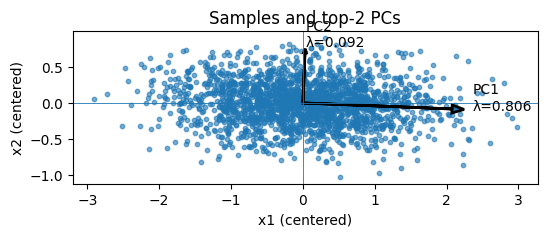

In [7]:
def gauss_distrib(theta, mu1, std1, mu2, std2, number_of_samples, number_of_neurons=2):
    samples = np.zeros((number_of_samples, number_of_neurons));
    for i in range(number_of_samples):
        u1 = np.random.random();
        u2 = np.random.random();
        T1 = np.sqrt(-2 * np.log(u1)) * np.cos(2*np.pi*u2);
        T2 = np.sqrt(-2 * np.log(u1)) * np.sin(2*np.pi*u2);
        
        samples[i,0] = mu1 +  (std1*T1 * np.cos(theta) - std2*T2 * np.sin(theta));
        samples[i,1] = mu2 +  (std1*T1 * np.sin(theta) + std2*T2 * np.cos(theta));	
    samples[:,0] -= np.mean(samples[:,0])
    samples[:,1] -=np.mean(samples[:,1])
    return samples

# We precompute the samples
samples_2d = gauss_distrib(orientation, mu1,std1,mu2,std2,number_of_samples)

# get eigenvalues
plot_samples_and_top2_pcs(samples_2d)

### Test samples: 3D

/var/folders/7_/28s2yvwn3q7dgbxbz546rc180000gn/T/ipykernel_70963/1885478904.py:5: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples_3d = np.random.multivariate_normal(mu, cov, size=number_of_samples)


{'pcs': array([[ 0.24283818,  0.96834434,  0.05778294],
        [ 0.56726624, -0.19007222,  0.80129992],
        [ 0.78691717, -0.1618079 , -0.59546584]]),
 'eigvals': array([1.70676756, 0.2083308 , 0.09134166]),
 'mean': array([ 5.27355937e-18, -1.23012711e-16, -1.00586206e-16])}

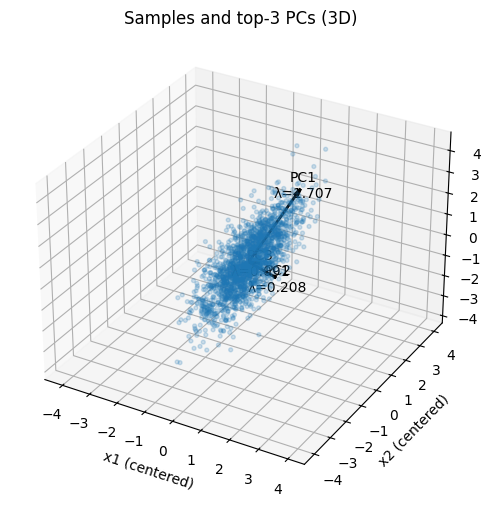

In [8]:
mu = np.array([0.0, 0.0, 0.0])   # means for 3 neurons
cov = np.array([[0.3, 0.2, 0.3],   # covariance matrix (3x3, symmetric, PSD)
                [0.2, 0.5, 0.8],
                [0.3, 0.8, 1.0]])
samples_3d = np.random.multivariate_normal(mu, cov, size=number_of_samples)

# Center the data (zero mean)
samples_3d -= samples_3d.mean(axis=0, keepdims=True)

plot_samples_and_top3_pcs_3d(samples_3d, center=True, scale=2.5, annotate=True)


### Test samples: N-D

### 2D Oja and Sanger multi-neuron networks

In [9]:
model1 = OjaNetwork(input_size=2, output_size=2, learning_rate=learning_rate)
model2 = SangerNetwork(input_size=2, output_size=2, learning_rate=learning_rate)

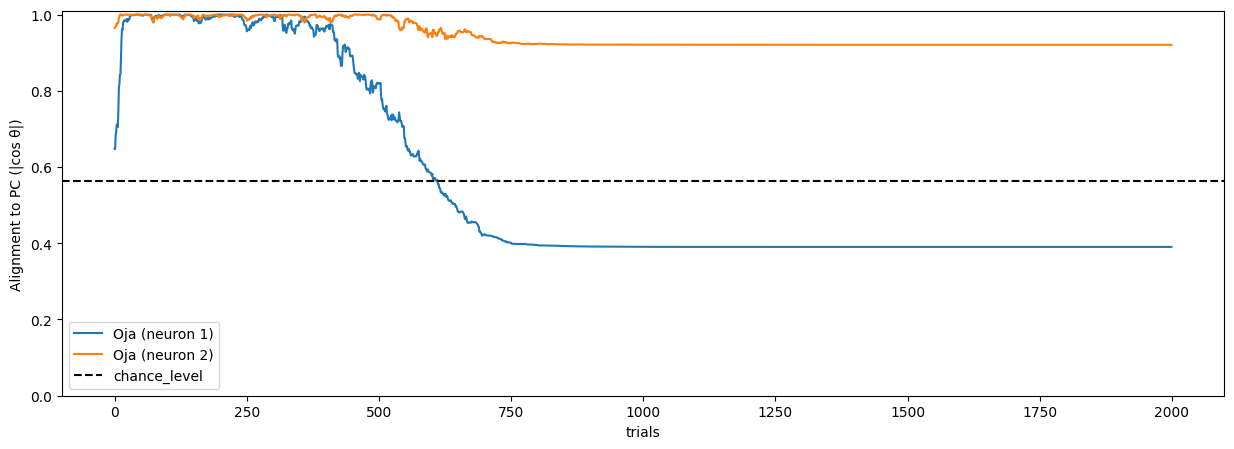

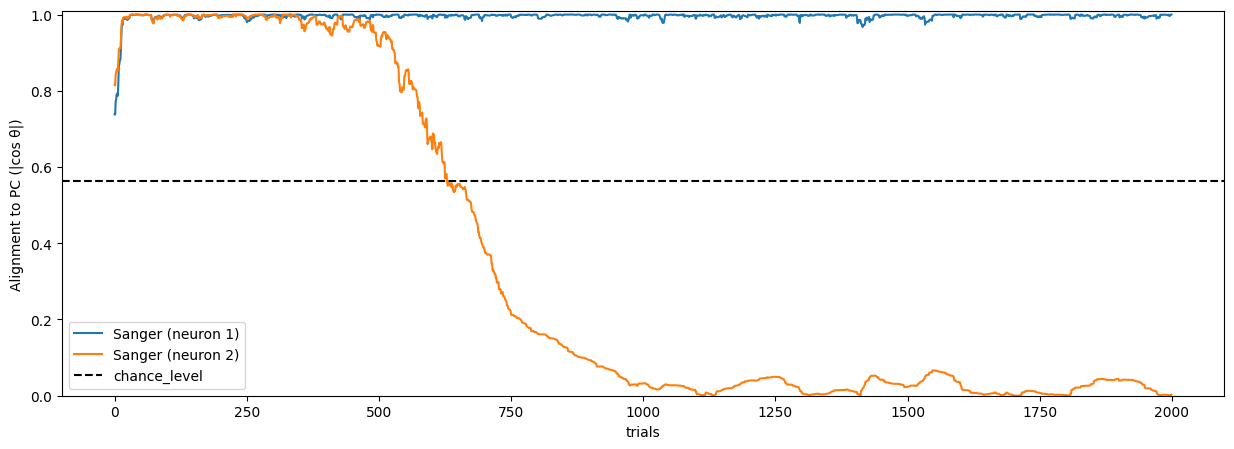

In [10]:
training_testing(samples_2d, models = {"Oja": model1, "Sanger": model2}, output_size=2,
                       pc_method = "first", alignment_method = "weights",
                       show_num = None)

### 3D Oja and Sanger multi-neuron networks

In [11]:
model1 = OjaNetwork(input_size=3, output_size=3, learning_rate=learning_rate)
model2 = SangerNetwork(input_size=3, output_size=3, learning_rate=learning_rate)

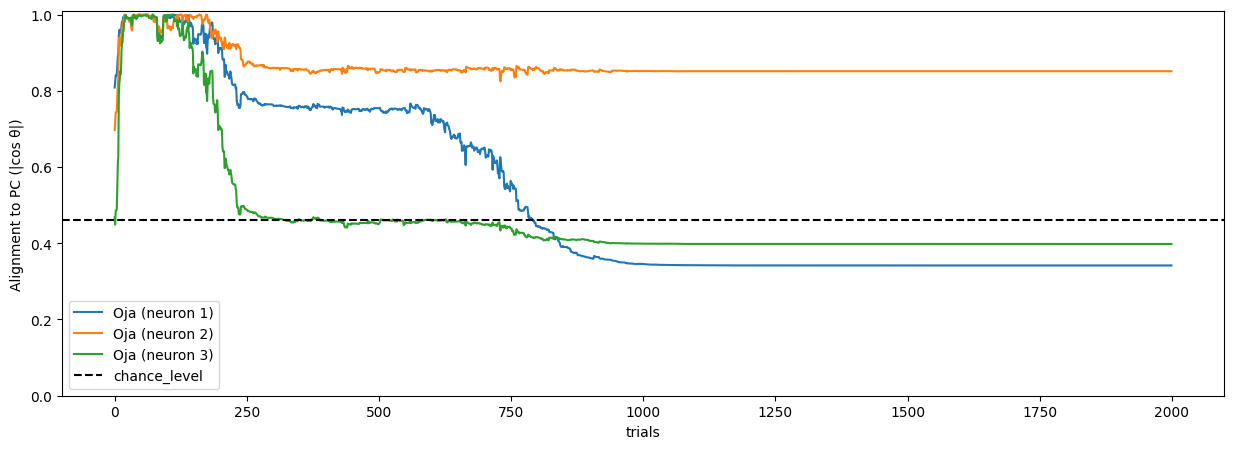

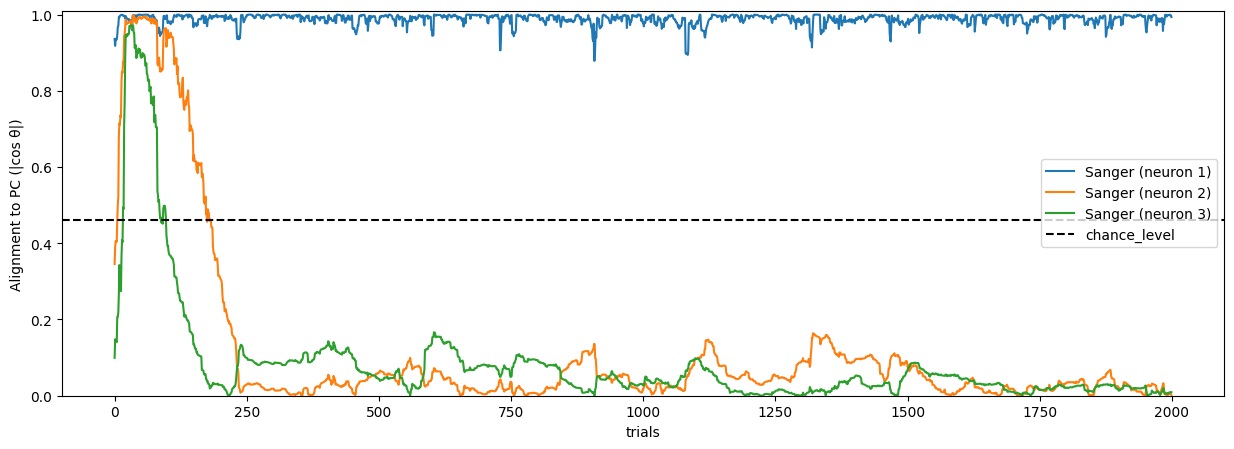

In [12]:
training_testing(samples_3d, models = {"Oja": model1, "Sanger": model2}, output_size=3,
                       pc_method = "first", alignment_method = "weights",
                       show_num = None)

### 3D Oja's and Sanger's multi-neuron model in 2D samples.

In [13]:
model1 = OjaNetwork(input_size=3, output_size=2, learning_rate=learning_rate)
model2 = SangerNetwork(input_size=3, output_size=2, learning_rate=learning_rate)

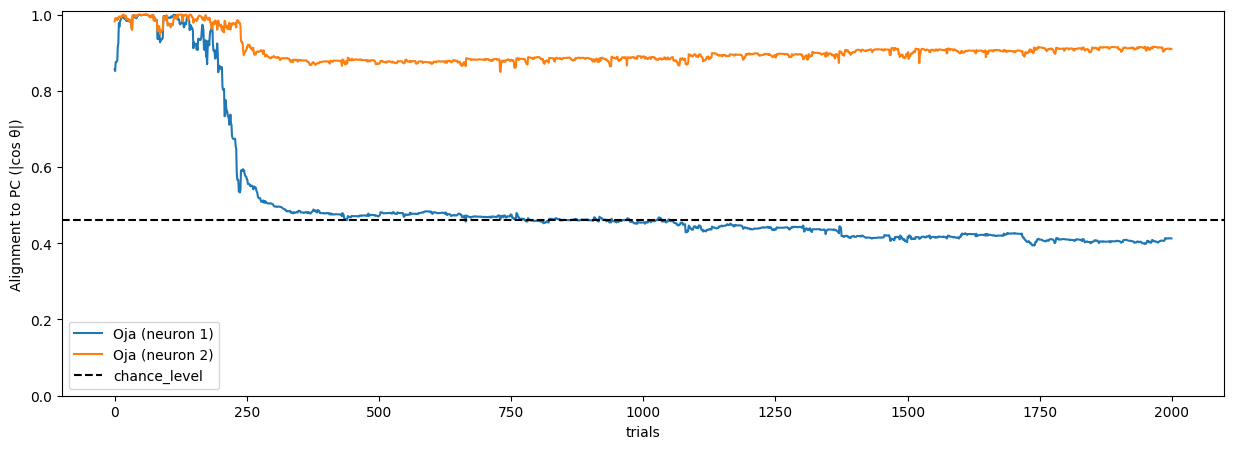

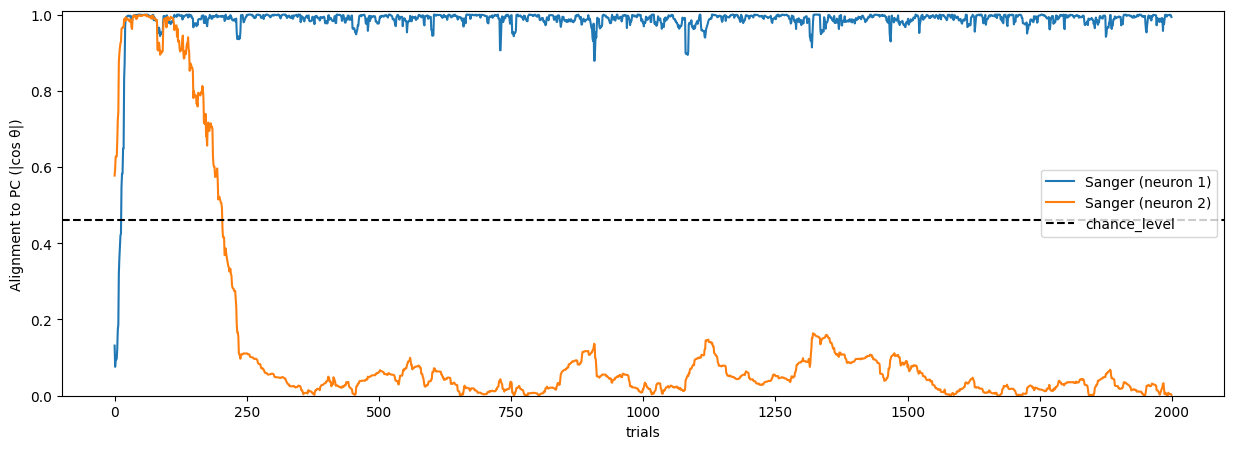

In [14]:
training_testing(samples_3d, models = {"Oja": model1, "Sanger": model2}, output_size=2,
                       pc_method = "first", alignment_method = "weights",
                       show_num = None)

### Oja and Sanger multi-neuron networks for N-D samples
N = 10

In [15]:
# 10-dimensional mean vector
mu = np.zeros(10)

# 10x10 covariance matrix (symmetric, PSD)
cov = generate_covariance_matrix(10, method = 'eigenvalues', eigenvalues = [1, 0.5, 0.3, 0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1])

# sample data
samples_10d = np.random.multivariate_normal(mu, cov, size=number_of_samples)


In [16]:
model1 = OjaNetwork(output_size=5, learning_rate=learning_rate)
model2 = SangerNetwork(output_size=5, learning_rate=learning_rate)

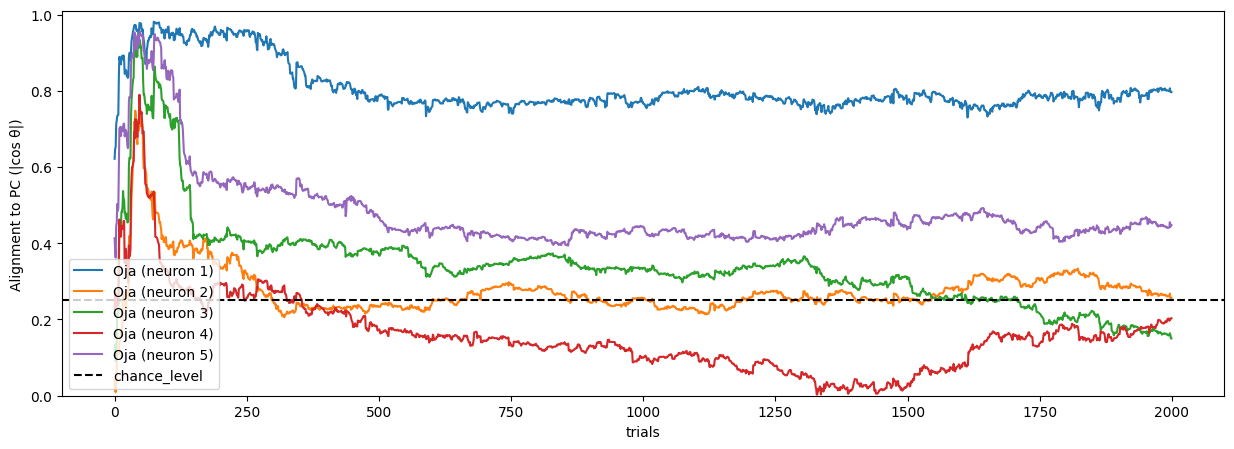

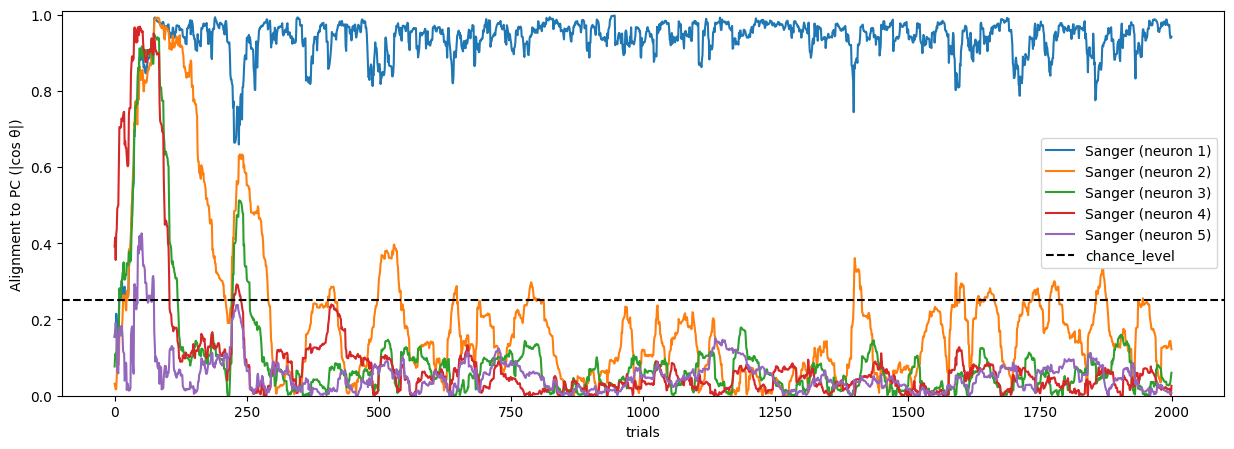

In [17]:
training_testing(samples_10d, models = {"Oja": model1, "Sanger": model2}, output_size=5, 
                pc_method = "first", alignment_method = "weights", show_num = None)

### Bonus: check the variances of output to align with eigenvalues

In [18]:
from hebbian.utils import estimate_output_variances

In [19]:
weights_ojaK = model1.W
weights_sangerK = model2.W

In [20]:
X = samples_10d
# Eigenvalue
print(f"PCs eigenvalues: {pca_topk(X, X.shape[1], center=True)[1]}")
print(f"Sanger: {estimate_output_variances(X, weights_sangerK)}")
print(f"Oja: {estimate_output_variances(X, weights_ojaK)}")

PCs eigenvalues: [0.97482409 0.49298161 0.2972068  0.19888072 0.10904547 0.10496721
 0.10373924 0.10018518 0.09634367 0.09551279]
Sanger: [0.89266508 0.4781367  0.30286927 0.18342478 0.1075866 ]
Oja: [0.67675154 0.222363   0.30090829 0.45437557 0.35166424]


### Bonus 2: Subspace check
The results of $\mathbf{w^\top w \approx I_n}$